In [1]:
import pandas as pd
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten
from tensorflow.keras import backend as K

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

(x_train,y_train),(x_test,y_test)=mnist.load_data()

x-train [Shape(60000, 28, 28)] sample patch 
 [[  0  76 246 252 112]
 [  0  85 252 230  25]
 [  0  85 252 223   0]
 [  0  85 252 145   0]
 [  0  86 253 225   0]]


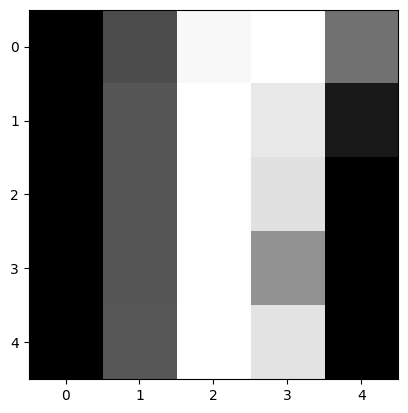

In [3]:
import matplotlib.pyplot as plt
print("x-train [Shape%s] sample patch \n"% (str(x_train.shape)),x_train[1,15:20,5:10])
plt.imshow(x_train[1,15:20,5:10],cmap='gray')
plt.show()

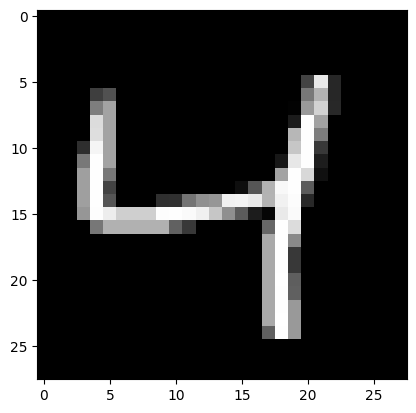

In [4]:
plt.imshow(x_train[2],cmap='gray')
plt.show()

In [5]:
import tensorflow as tf
# Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32')/255.0 #scaling min max scaler
x_test = x_test.astype('float32')/255.0
#flatten the image (28*28 into 784)
x_train = x_train.reshape(x_train.shape[0],-1)
x_test = x_test.reshape(x_test.shape[0],-1)

# one-hot encoding lable
y_train=tf.keras.utils.to_categorical(y_train,num_classes=10)
y_test=tf.keras.utils.to_categorical(y_test,num_classes=10)

model = tf.keras.Sequential([
   tf.keras.layers.Dense(200,activation='relu',input_shape=(784,)),
   tf.keras.layers.Dense(100,activation='relu'),
   tf.keras.layers.Dense(60,activation='relu'),
   tf.keras.layers.Dense(30,activation='relu'),
   tf.keras.layers.Dense(10,activation='softmax')
])
model.summary()

c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 60)             │         6,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,300 (723.83 KB)

 Trainable params: 185,300 (723.83 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


In [7]:
history = model.fit(x_train,y_train,epochs=10,batch_size=64,validation_split=0.2)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.1035 - loss: 31.9092 - val_accuracy: 0.0956 - val_loss: 2.3139
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.1027 - loss: 2.3231 - val_accuracy: 0.1035 - val_loss: 2.3315
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.1021 - loss: 2.3253 - val_accuracy: 0.1060 - val_loss: 2.3460
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.1037 - loss: 2.3251 - val_accuracy: 0.0995 - val_loss: 2.3492
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.1025 - loss: 2.3252 - val_accuracy: 0.0975 - val_loss: 2.3421
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.1013 - loss: 2.3261 - val_accuracy: 0.1060 - val_loss: 2.3396
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.1015 - loss: 2.3264 - val_accuracy: 0.0997 - val_loss: 2.3175
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.1017 - loss: 2.3307 - va

In [8]:
test_loss,test_acc= model.evaluate(x_test,y_test)
print('Test accuracy : {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.1135 - loss: 2.3369
Test accuracy : {test_acc}


In [9]:
import numpy as np 
def get_random_indices(total_image,num_images):
   indices = np.random.choice(total_image,num_images,replace=False)
   return indices

In [ ]:
predictions = model.predict(x_test)
x_test_image = x_test.reshape(-1,28,28)
prediction_classes=np.argmax(predictions,axis=1)
true_classes = np.argmax(y_test,axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [21]:
from numpy.random import f
num_images_to_show=5
random_indices=get_random_indices(len(x_test_image),num_images_to_show)
def plot_images(images,labels,predictions):
   plt.figure(figsize=(10,9))
   for i in range(len(images)):
      plt.subplot(1,len(images),i+1)
      plt.imshow(images[i],cmap='gray')
      plt.title(f'Actual:{labels[i]},\n Prediction {predictions[i]}')
      plt.axis('off')
   plt.show()

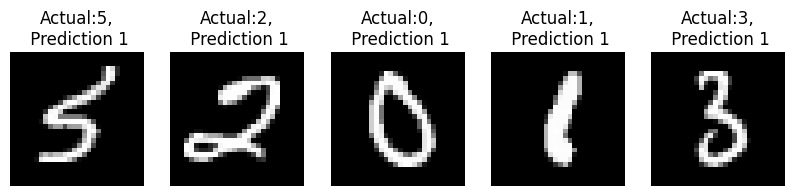

In [22]:
plot_images(x_test_image[random_indices],true_classes[random_indices],prediction_classes[random_indices])

In [24]:
!pip install TensorBoard


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard
list_activation = {'sigmoid','relu','tanh'}
list_optimizers = {'adam','rmsprop'}
NAME = 'mnist-28-28-v1'
tensorboard = TensorBoard(log_dir='logs/{}'.format(NAME))
# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
 
x_train = x_train.astype('float32') / 255.0# scaling min max scaler
x_test = x_test.astype('float32') /255.0
#flatten the images (28*28 into 784)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
#one - hot encoding labels
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)
for act in list_activation:
   for op in list_optimizers:
       Name=f'{act}-{op}-{i}'
       i+=1
       print(Name)     
       model = tf.keras.Sequential([
            tf.keras.layers.Dense(200, activation = 'relu', input_shape =(784,)),
            tf.keras.layers.Dense(100, activation = 'relu'),
            tf.keras.layers.Dense(60, activation = 'relu'),
            tf.keras.layers.Dense(30, activation = 'relu'),
            tf.keras.layers.Dense(10, activation = 'softmax')
        ])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
historty = model.fit(x_train,y_train, epochs =10, batch_size=64, validation_split=0.2, callbacks=[tensorboard])
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc}')
#
 
 

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.1131 - loss: 2.3014 - val_accuracy: 0.1060 - val_loss: 2.3022
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.1140 - loss: 2.3012 - val_accuracy: 0.1060 - val_loss: 2.3023
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.1140 - loss: 2.3012 - val_accuracy: 0.1060 - val_loss: 2.3020
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.1140 - loss: 2.3012 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.1140 - loss: 2.3012 - val_accuracy: 0.1060 - val_loss: 2.3022
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.1140 - loss: 2.3012 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.1140 - loss: 2.3012 - val_accuracy: 0.1060 - val_loss: 2.3020
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.1140 - loss: 2.3011 - va

In [30]:
%load_ext tensorboard
%tensorboard --logdir logs

In [ ]:
!tensorboard --logdir=logs --port=6006

C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorboard\default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
I0000 00:00:1775678650.606239   26008 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775678653.551955   26008 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
usage: tensorboard [-h] [--helpfull] [--logdir PATH] [--logdir_spec PATH_SPE